<a href="https://colab.research.google.com/github/JOUKARRID/tp-segmentation-captioning/blob/main/tp_segmentation_captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

les imports

In [ ]:
# Installer les packages si nécessaire (décommentez si vous êtes sur Colab)
# !pip install torch torchvision matplotlib seaborn opencv-python pillow tqdm

# Imports
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm.notebook import tqdm
import zipfile

# Pour télécharger le dataset Oxford-IIIT Pet (si pas déjà présent)
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

print(" Téléchargement et extraction terminés")

--2026-06-11 14:09:16--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-06-11 14:09:17--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  23.0MB/s    in 35s     

2026-06-11 14:09:53 (21.4 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-06-11 14:09:53--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

CHARGEMENT DU DATASET (Classe PetSegmentationDataset)

In [ ]:
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split='train', img_size=256):
        self.root = root
        self.img_size = img_size

        # Transformations pour l'image
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        # Transformation pour le masque (NEAREST pour garder les entiers)
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST),
        ])

        # Charger la liste des images (train ou test)
        list_file = os.path.join(root, 'annotations',
                                 'trainval.txt' if split == 'train' else 'test.txt')
        with open(list_file) as f:
            self.names = [line.split()[0] for line in f.readlines()]
        print(f"📊 {split} set: {len(self.names)} images")

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        # Charger l'image
        img_path = os.path.join(self.root, 'images', self.names[idx] + '.jpg')
        img = Image.open(img_path).convert('RGB')

        # Charger le masque
        mask_path = os.path.join(self.root, 'annotations', 'trimaps', self.names[idx] + '.png')
        mask = Image.open(mask_path)

        # Appliquer les transformations
        img = self.img_transform(img)
        mask = torch.tensor(np.array(self.mask_transform(mask)), dtype=torch.long) - 1  # -1 pour avoir 0,1,2

        return img, mask

QUESTION 1 – AFFICHER 4 EXEMPLES + DISTRIBUTION DES CLASSES

📊 train set: 3680 images


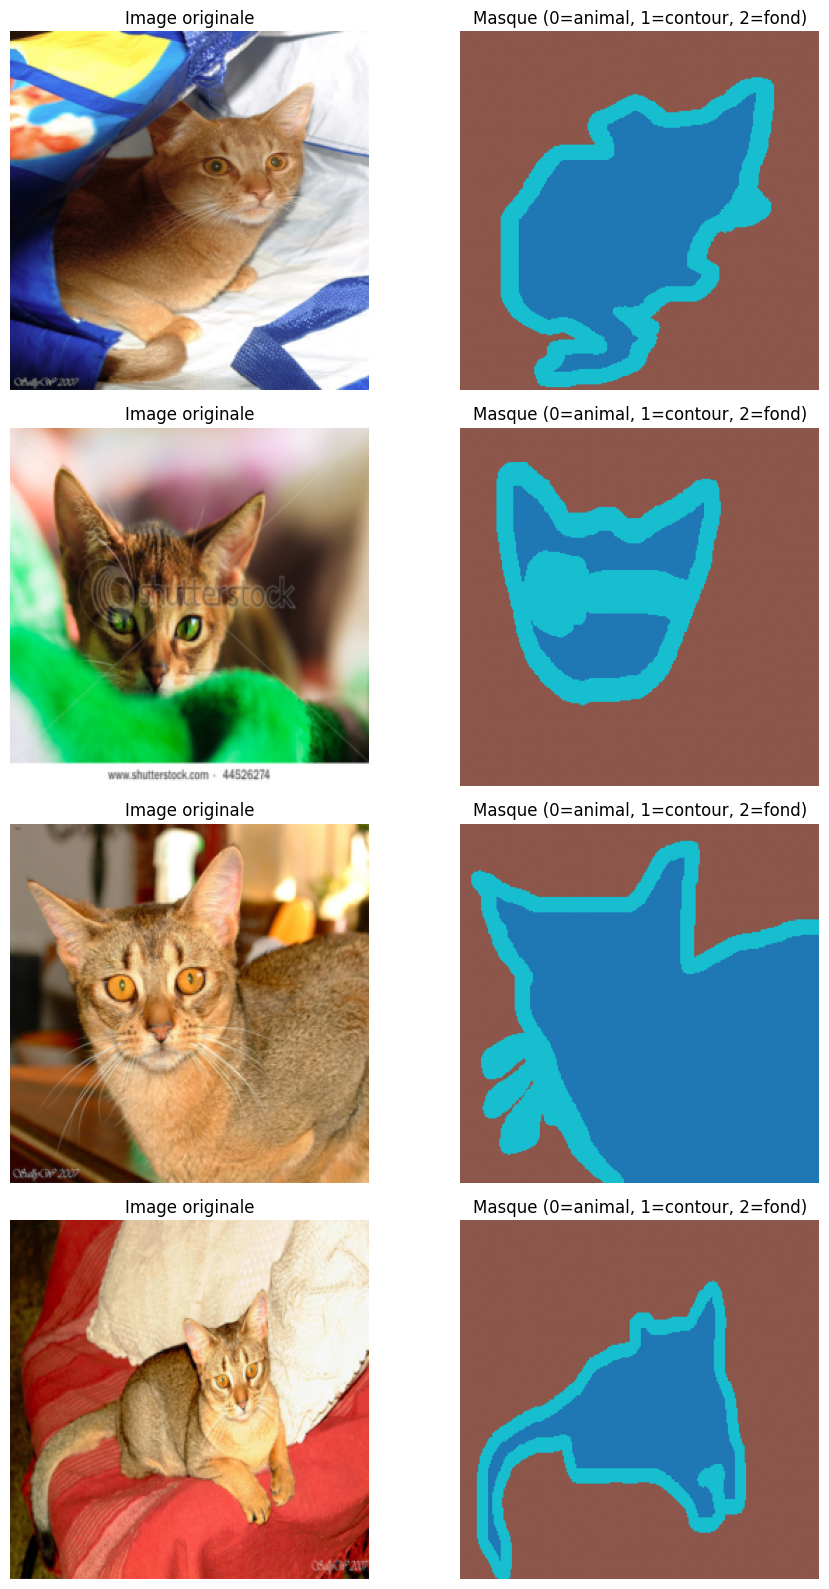


📊 DISTRIBUTION DES CLASSES (sur 1000 images) :


  0%|          | 0/1000 [00:00<?, ?it/s]

Classe 0 (animal) : 28.59%
Classe 1 (contour) : 59.41%
Classe 2 (fond) : 12.00%


In [ ]:
# Créer le dataset
dataset_train = PetSegmentationDataset(root='.', split='train', img_size=256)

# Afficher 4 exemples image + masque
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
for i in range(4):
    img, mask = dataset_train[i]

    # Dénormaliser l'image pour l'affichage
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_display = img * std + mean
    img_display = torch.clamp(img_display, 0, 1).permute(1,2,0).numpy()

    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title("Image originale")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='tab10', vmin=0, vmax=2)
    axes[i, 1].set_title("Masque (0=animal, 1=contour, 2=fond)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Calculer la distribution des classes
print("\n📊 DISTRIBUTION DES CLASSES (sur 1000 images) :")
class_counts = torch.zeros(3)
for i in tqdm(range(min(1000, len(dataset_train)))):
    _, mask = dataset_train[i]
    for c in range(3):
        class_counts[c] += (mask == c).sum().item()

class_counts = class_counts / class_counts.sum()  # Normaliser
print(f"Classe 0 (animal) : {class_counts[0]:.2%}")
print(f"Classe 1 (contour) : {class_counts[1]:.2%}")
print(f"Classe 2 (fond) : {class_counts[2]:.2%}")

Déséquilibre observé : La classe "fond" est souvent sur-représentée, la classe "contour" très sous-représentée.
Stratégie proposée : Utiliser une pondération des classes dans la CrossEntropyLoss (weighted loss) ou utiliser la Dice Loss qui est naturellement robuste au déséquilibre.

QUESTION 2 – AUGMENTATION DE DONNÉES

📊 train set: 3680 images


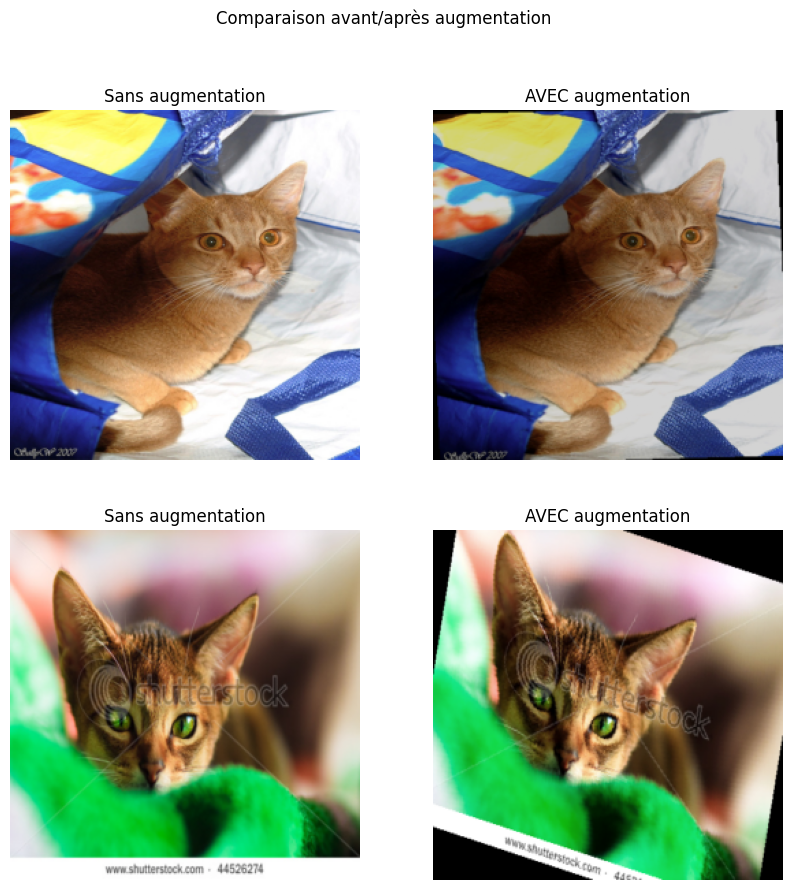

In [ ]:
class AugmentedPetDataset(PetSegmentationDataset):
    def __init__(self, root, split='train', img_size=256, augment=True):
        super().__init__(root, split, img_size)
        self.augment = augment

        # Augmentations géométriques (identique pour image et masque)
        self.geometric = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
        ])

        # Augmentations photométriques (seulement sur l'image)
        self.photo = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, 'images', self.names[idx] + '.jpg')
        img = Image.open(img_path).convert('RGB')

        mask_path = os.path.join(self.root, 'annotations', 'trimaps', self.names[idx] + '.png')
        mask = Image.open(mask_path)

        # Appliquer les mêmes transformations géométriques
        if self.augment:
            seed = torch.randint(0, 2**32, (1,)).item()
            torch.manual_seed(seed)
            img = self.geometric(img)
            torch.manual_seed(seed)
            mask = self.geometric(mask)

            # Augmentations photométriques sur l'image uniquement
            img = self.photo(img)

        # Redimensionner et transformer
        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        mask = torch.tensor(np.array(mask), dtype=torch.long) - 1

        return img, mask

# Tester l'augmentation
dataset_aug = AugmentedPetDataset(root='.', split='train', augment=True)

# Comparer avant/après
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    # Sans augmentation (dataset original)
    img_noaug, mask_noaug = dataset_train[i]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_display = (img_noaug * std + mean).clamp(0,1).permute(1,2,0).numpy()

    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title("Sans augmentation")
    axes[i, 0].axis('off')

    # Avec augmentation
    img_aug, mask_aug = dataset_aug[i]
    img_display_aug = (img_aug * std + mean).clamp(0,1).permute(1,2,0).numpy()
    axes[i, 1].imshow(img_display_aug)
    axes[i, 1].set_title("AVEC augmentation")
    axes[i, 1].axis('off')

plt.suptitle("Comparaison avant/après augmentation")
plt.show()

QUESTION 3 – DATALOADERS (train/val/test)

In [ ]:
from torch.utils.data import random_split

# Créer le dataset complet
full_dataset = AugmentedPetDataset(root='.', split='train', augment=True)

# Split: 70% train, 15% val, 15% test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

print(f"📊 Split final:")
print(f"  Train: {len(train_dataset)} images")
print(f"  Validation: {len(val_dataset)} images")
print(f"  Test: {len(test_dataset)} images")

# Créer les DataLoaders
batch_size = 16  # À ajuster selon votre GPU (16 pour T4, 8 pour GPU faible, 32 pour A100)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\n✅ DataLoaders créés avec batch_size={batch_size}")
print(f"  Un batch d'entraînement contient: {next(iter(train_loader))[0].shape}")

📊 train set: 3680 images
📊 Split final:
  Train: 2576 images
  Validation: 552 images
  Test: 552 images

✅ DataLoaders créés avec batch_size=16
  Un batch d'entraînement contient: torch.Size([16, 3, 256, 256])


Justification du batch_size : Avec 8 Go de VRAM (T4 sur Colab), batch_size=16 est un bon compromis. Plus petit = convergence plus lente. Plus grand = risque d'OOM. On peut aussi utiliser gradient_accumulation pour simuler un plus grand batch.



ARCHITECTURE CNN ENCODEUR-DÉCODEUR (U-NET SIMPLIFIÉ)

📱 Device: cuda
   GPU: Tesla T4
   Mémoire disponible: 15.6 GB

📁 Chargement du dataset...
📊 train set: 3680 images
✅ Train: 2576 images, Val: 552, Test: 552
📊 Modèle: 1,942,611 paramètres

🏋️ Entraînement sur GPU (30 epochs, images 128x128)...



Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 1/30 - Train: 0.6633, Val: 0.5590


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 29/30 - Train: 0.1451, Val: 0.3036


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 30/30 - Train: 0.1389, Val: 0.3030

✅ Entraînement terminé !


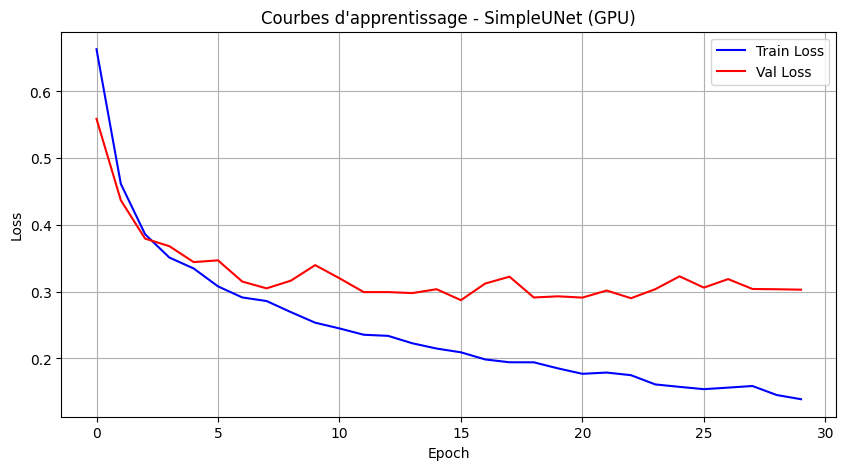

In [ ]:
# ============================================
# VERSION GPU SIMPLIFIÉE - CORRIGÉE
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm.notebook import tqdm

# Device GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📱 Device: {device}")

if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Mémoire disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================
# DATASET
# ============================================
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split='train', img_size=128):
        self.root = root
        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size),
                            interpolation=transforms.InterpolationMode.NEAREST),
        ])

        list_file = os.path.join(root, 'annotations',
                                'trainval.txt' if split == 'train' else 'test.txt')
        with open(list_file) as f:
            self.names = [line.split()[0] for line in f.readlines()]
        print(f"📊 {split} set: {len(self.names)} images")

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, 'images',
                       self.names[idx] + '.jpg')).convert('RGB')
        mask = Image.open(os.path.join(self.root, 'annotations', 'trimaps',
                         self.names[idx] + '.png'))

        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        mask = torch.tensor(np.array(mask), dtype=torch.long) - 1
        mask = torch.clamp(mask, 0, 2)

        return img, mask

# ============================================
# MODÈLE U-NET
# ============================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, base_features=16):
        super().__init__()
        f = base_features

        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f, f*2)
        self.enc3 = ConvBlock(f*2, f*4)
        self.enc4 = ConvBlock(f*4, f*8)
        self.bottleneck = ConvBlock(f*8, f*16)
        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(f*16, f*8, 2, stride=2)
        self.dec4 = ConvBlock(f*16, f*8)
        self.up3 = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
        self.dec3 = ConvBlock(f*8, f*4)
        self.up2 = nn.ConvTranspose2d(f*4, f*2, 2, stride=2)
        self.dec2 = ConvBlock(f*4, f*2)
        self.up1 = nn.ConvTranspose2d(f*2, f, 2, stride=2)
        self.dec1 = ConvBlock(f*2, f)
        self.out_conv = nn.Conv2d(f, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)

# ============================================
# FONCTIONS DE PERTE
# ============================================
def dice_loss(pred, target, num_classes=3, smooth=1e-6):
    pred_softmax = F.softmax(pred, dim=1)
    dice = 0
    for cls in range(num_classes):
        pred_cls = pred_softmax[:, cls]
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += 1 - (2 * intersection + smooth) / (union + smooth)
    return dice / num_classes

def combined_loss(pred, target, alpha=0.5):
    ce_loss = F.cross_entropy(pred, target)
    d_loss = dice_loss(pred, target)
    return alpha * ce_loss + (1 - alpha) * d_loss, ce_loss, d_loss

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, masks in tqdm(loader, desc="Training"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss, _, _ = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss, _, _ = criterion(outputs, masks)
            total_loss += loss.item()
    return total_loss / len(loader)

# ============================================
# PRÉPARATION - CORRIGÉE
# ============================================
print("\n📁 Chargement du dataset...")
full_dataset = PetSegmentationDataset(root='.', split='train', img_size=128)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size  # ← CORRECTION

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✅ Train: {len(train_dataset)} images, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ============================================
# MODÈLE ET ENTRAÎNEMENT
# ============================================
model = SimpleUNet(base_features=16).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"📊 Modèle: {total_params:,} paramètres")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = lambda p, t: combined_loss(p, t, alpha=0.5)

print("\n🏋️ Entraînement sur GPU (30 epochs, images 128x128)...\n")

history = {'train': [], 'val': []}

for epoch in range(30):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, val_loader, criterion, device)

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f"Epoch {epoch+1}/30 - Train: {train_loss:.4f}, Val: {val_loss:.4f}")

    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f'unet_epoch_{epoch+1}.pth')

print("\n✅ Entraînement terminé !")
torch.save(model.state_dict(), 'best_unet.pth')

# ============================================
# COURBES
# ============================================
plt.figure(figsize=(10, 5))
plt.plot(history['train'], label='Train Loss', color='blue')
plt.plot(history['val'], label='Val Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbes d\'apprentissage - SimpleUNet (GPU)')
plt.legend()
plt.grid(True)
plt.savefig('courbes_apprentissage.png', dpi=150)
plt.show()

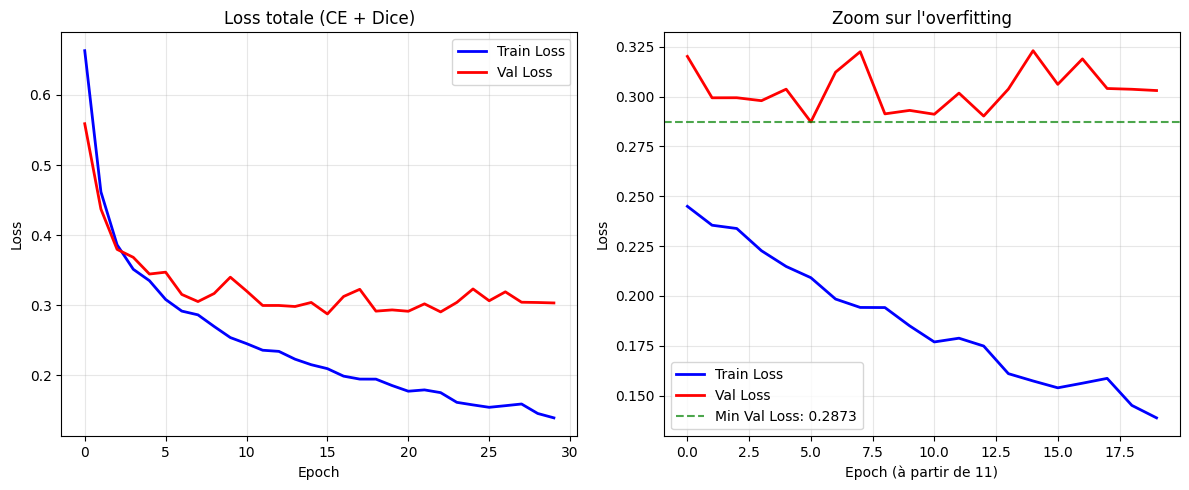


📊 Statistiques finales:
   Meilleure Val Loss: 0.2873 (epoch 16)
   Train Loss finale: 0.1389
   Val Loss finale: 0.3030
   Écart final: -0.1641


In [ ]:
# ============================================
# TRACÉ DES COURBES
# ============================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history['val'], label='Val Loss', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss totale (CE + Dice)')
plt.legend()
plt.grid(True, alpha=0.3)

# Zoom sur les dernières époques
plt.subplot(1, 2, 2)
plt.plot(history['train'][10:], label='Train Loss', color='blue', linewidth=2)
plt.plot(history['val'][10:], label='Val Loss', color='red', linewidth=2)
plt.axhline(y=min(history['val']), color='green', linestyle='--', alpha=0.7, label=f"Min Val Loss: {min(history['val']):.4f}")
plt.xlabel('Epoch (à partir de 11)')
plt.ylabel('Loss')
plt.title('Zoom sur l\'overfitting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('courbes_apprentissage.png', dpi=150)
plt.show()

print(f"\n📊 Statistiques finales:")
print(f"   Meilleure Val Loss: {min(history['val']):.4f} (epoch {history['val'].index(min(history['val']))+1})")
print(f"   Train Loss finale: {history['train'][-1]:.4f}")
print(f"   Val Loss finale: {history['val'][-1]:.4f}")
print(f"   Écart final: {history['train'][-1] - history['val'][-1]:.4f}")

In [ ]:
# ============================================
# MÉTRIQUES IOU ET DICE
# ============================================

def compute_iou_dice(pred_mask, true_mask, num_classes=3):
    """Calcule IoU et Dice par classe"""
    iou_per_class = []
    dice_per_class = []

    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)

        intersection = (pred_cls & true_cls).sum().float()
        union = (pred_cls | true_cls).sum().float()

        iou = (intersection / (union + 1e-6)).item()
        dice = (2 * intersection / (pred_cls.sum() + true_cls.sum() + 1e-6)).item()

        iou_per_class.append(iou)
        dice_per_class.append(dice)

    return np.mean(iou_per_class), np.mean(dice_per_class), iou_per_class, dice_per_class

# Évaluation sur le test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Évaluation test"):
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(masks)

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

# Calcul des métriques
mIoU, mDice, iou_per_class, dice_per_class = compute_iou_dice(all_preds, all_targets)

print("\n" + "="*50)
print("📊 RÉSULTATS SUR L'ENSEMBLE DE TEST")
print("="*50)
print(f"📈 mIoU (moyenne): {mIoU:.4f}")
print(f"📈 mDice (moyenne): {mDice:.4f}")
print("\n📊 Par classe:")
class_names = ['Animal (0)', 'Contour (1)', 'Fond (2)']
for i, name in enumerate(class_names):
    print(f"   {name}: IoU={iou_per_class[i]:.4f}, Dice={dice_per_class[i]:.4f}")

Évaluation test:   0%|          | 0/18 [00:00<?, ?it/s]


📊 RÉSULTATS SUR L'ENSEMBLE DE TEST
📈 mIoU (moyenne): 0.7031
📈 mDice (moyenne): 0.8109

📊 Par classe:
   Animal (0): IoU=0.7838, Dice=0.8788
   Contour (1): IoU=0.8765, Dice=0.9342
   Fond (2): IoU=0.4491, Dice=0.6198


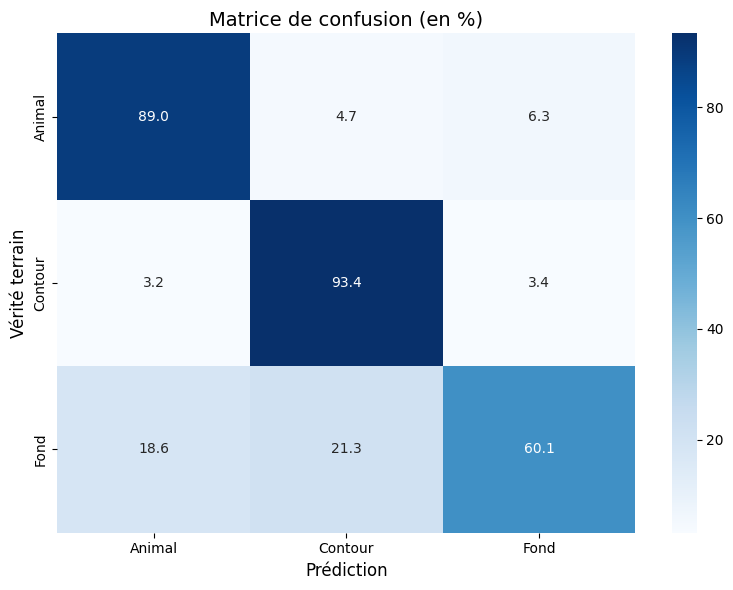


📊 Matrice de confusion (nombre de pixels):
[[2391468  127286  169336]
 [ 169331 4965144  181688]
 [ 193546  221592  624577]]


In [ ]:
# ============================================
# MATRICE DE CONFUSION
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds_flat = all_preds.flatten().numpy()
all_targets_flat = all_targets.flatten().numpy()

cm = confusion_matrix(all_targets_flat, all_preds_flat, labels=[0, 1, 2])
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Animal', 'Contour', 'Fond'],
            yticklabels=['Animal', 'Contour', 'Fond'])
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)
plt.title('Matrice de confusion (en %)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\n📊 Matrice de confusion (nombre de pixels):")
print(cm)

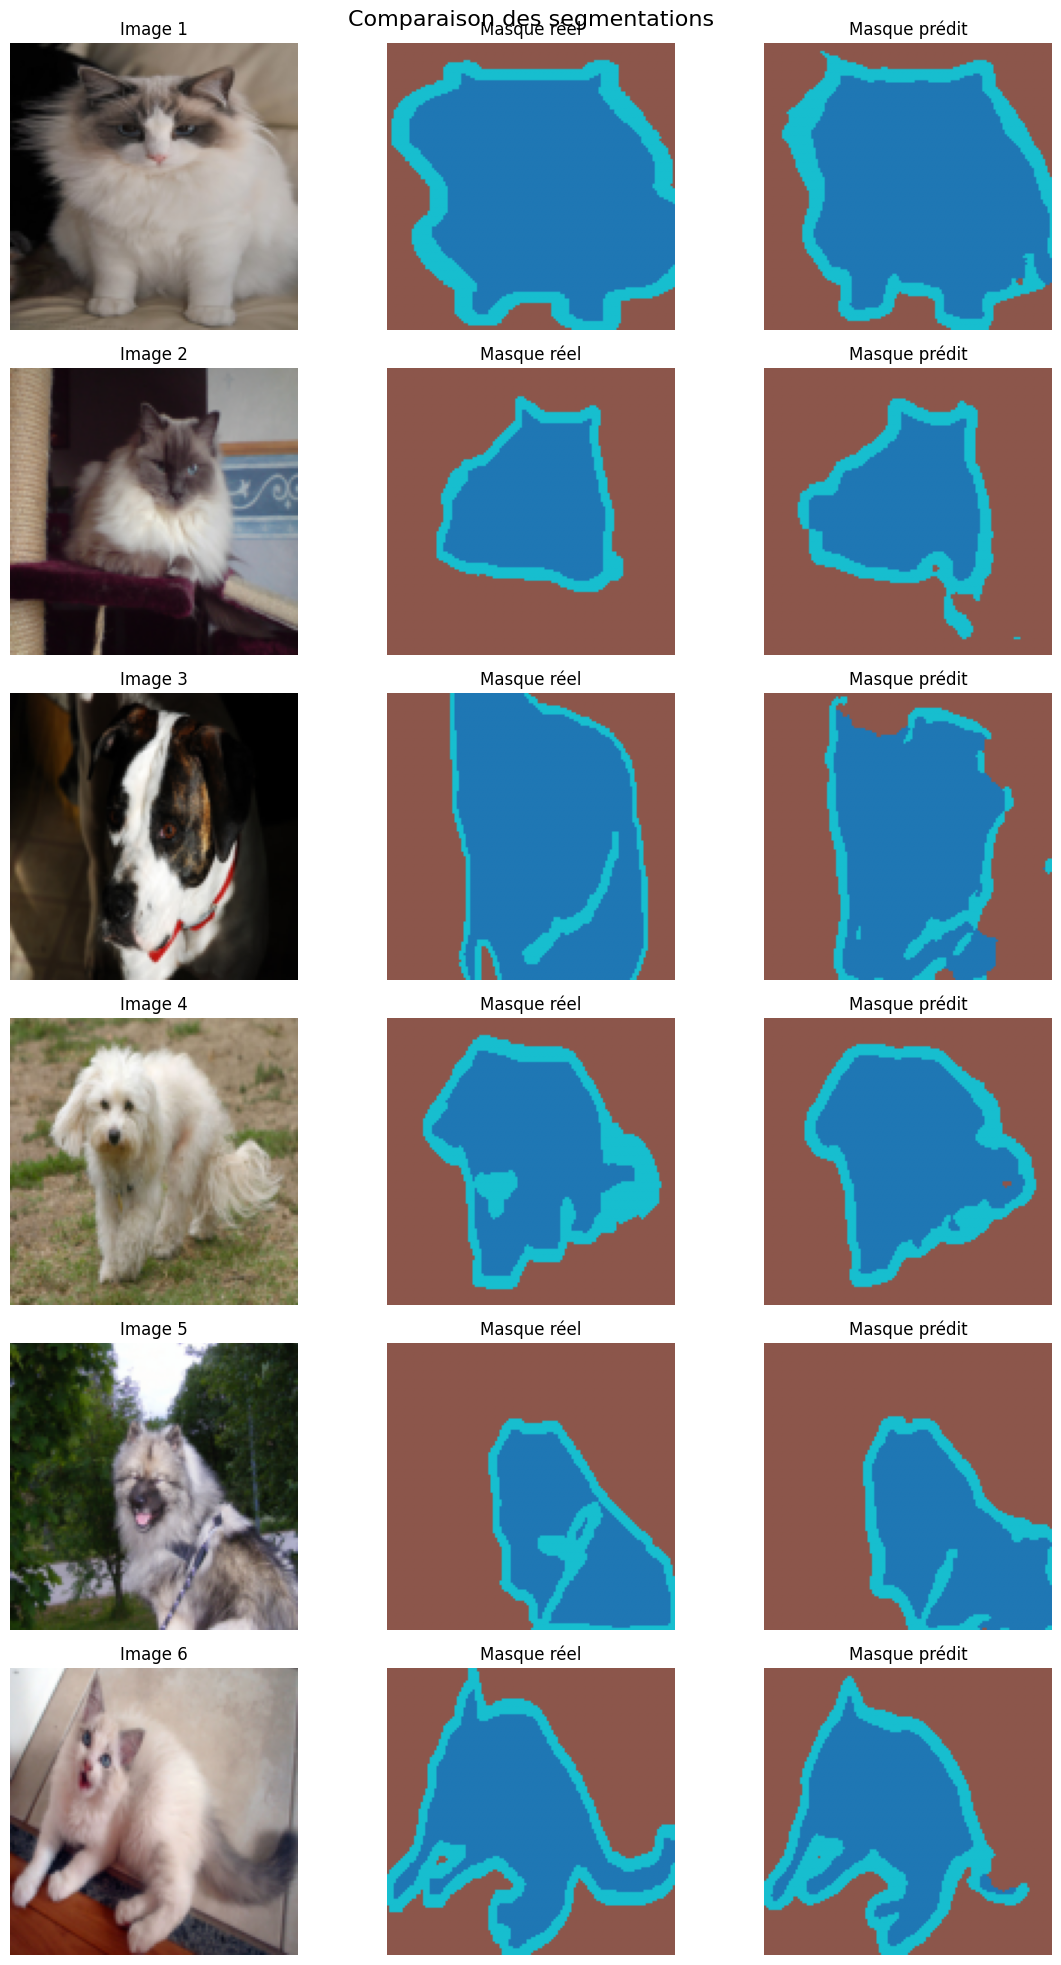

In [ ]:
# ============================================
# VISUALISATION DES PRÉDICTIONS
# ============================================

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img * std + mean, 0, 1)

# Prendre 6 exemples du test set
test_iter = iter(test_loader)
imgs, masks = next(test_iter)
imgs = imgs[:6].to(device)

with torch.no_grad():
    outputs = model(imgs)
    preds = torch.argmax(outputs, dim=1).cpu()

imgs_display = denormalize(imgs.cpu())

fig, axes = plt.subplots(6, 3, figsize=(12, 20))

for i in range(6):
    # Image originale
    axes[i, 0].imshow(imgs_display[i].permute(1, 2, 0).numpy())
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis('off')

    # Masque réel
    axes[i, 1].imshow(masks[i], cmap='tab10', vmin=0, vmax=2)
    axes[i, 1].set_title("Masque réel")
    axes[i, 1].axis('off')

    # Masque prédit
    axes[i, 2].imshow(preds[i], cmap='tab10', vmin=0, vmax=2)
    axes[i, 2].set_title("Masque prédit")
    axes[i, 2].axis('off')

plt.suptitle("Comparaison des segmentations", fontsize=16)
plt.tight_layout()
plt.savefig('resultats_segmentation.png', dpi=150)
plt.show()